<div style="background-color:#7BAFD4;border-radius:18px;padding:22px 26px;margin-bottom:18px;">
<div style="font-family:Impact,'Arial Black',Arial,sans-serif;font-size:42px;font-weight:900;letter-spacing:2px;line-height:1;color:white;">GEOG 592</div>
<div style="font-family:Arial,Helvetica,sans-serif;font-size:22px;font-weight:700;color:#13294B;margin-top:8px;">GIS Programming</div>
<div style="font-family:Arial,Helvetica,sans-serif;font-size:16px;color:#13294B;margin-top:6px;">GeoPandas — GeoDataFrames and Geometry</div></div>

# From pandas DataFrames to spatial DataFrames

GeoPandas extends pandas by adding geometry and coordinate reference system information.

By the end of this module, you should be able to read spatial data, identify a GeoDataFrame, inspect geometry and CRS, recognize geometry types, use familiar pandas operations, and make a quick map.


## Why GeoPandas matters

A GIS dataset is more than a table. Each row can also contain a geometry.


In [23]:
# Run this only if geopandas is not installed.
%pip install geopandas

Note: you may need to restart the kernel to use updated packages.


In [24]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

## Read a spatial file

In [25]:
stops = gpd.read_file("../Geopandas1/data/bus_stops.geojson")
# originally from https://gis-portal.townofchapelhill.org/server/rest/services/OpenData/Bus_Stops/FeatureServer/0/query?where=1%3D1&outFields=*&returnGeometry=true&outSR=4326&f=geojson
# https://gis-portal.townofchapelhill.org/server/rest/services/
# Useful API Code: 0/query?where=1%3D1&outFields=*&returnGeometry=true&outSR=4326&f=geojson

stops

stops = stops.set_crs(epsg = 26917, allow_override=True)
stops= stops.to_crs(epsg=4326)


In [26]:
type(stops)

geopandas.geodataframe.GeoDataFrame

## Familiar pandas operations still work

In [27]:
stops.head()

,stop_id,stop_name,geometry
0,1,Stop A,POINT (-67.71936 6.9565)
1,2,Stop B,POINT (-67.71397 6.95987)
2,3,Stop C,POINT (-67.70947 6.96326)
3,4,Stop D,POINT (-67.70434 6.95783)
4,5,Stop E,POINT (-67.69975 6.96386)


In [28]:
stops.shape

(5, 3)

In [29]:
stops.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [30]:
stops.columns

Index(['stop_id', 'stop_name', 'geometry'], dtype='str')

In [31]:
print(stops[["stop_name","geometry"]])
print(type(stops[["stop_name","geometry"]]))

  stop_name                   geometry
0    Stop A   POINT (-67.71936 6.9565)
1    Stop B  POINT (-67.71397 6.95987)
2    Stop C  POINT (-67.70947 6.96326)
3    Stop D  POINT (-67.70434 6.95783)
4    Stop E  POINT (-67.69975 6.96386)
<class 'geopandas.geodataframe.GeoDataFrame'>


## The geometry column

In [32]:
print(stops.geometry.head())
print(type(stops.geometry))

0     POINT (-67.71936 6.9565)
1    POINT (-67.71397 6.95987)
2    POINT (-67.70947 6.96326)
3    POINT (-67.70434 6.95783)
4    POINT (-67.69975 6.96386)
Name: geometry, dtype: geometry
<class 'geopandas.geoseries.GeoSeries'>


In [33]:
first_geometry = stops.geometry.iloc[0]
print(first_geometry)
print(type(first_geometry))

POINT (-67.71936112339672 6.95649634491994)
<class 'shapely.geometry.point.Point'>


Remember what you know about objects and dot notation:

- `stops` is a GeoDataFrame object
- `stops.geometry` is an attribute
- `stops.head()` is a method
- each individual geometry is also an object


## Geometry types

In [34]:
stops.geom_type

0    Point
1    Point
2    Point
3    Point
4    Point
dtype: str

In [35]:
urban_area = gpd.read_file("../Geopandas1/data/districts.geojson")
## from https://gis-portal.townofchapelhill.org/server/rest/services/OpenData/UrbanServiceBoundary/FeatureServer/0/query?where=1%3D1&outFields=*&returnGeometry=true&outSR=4326&f=geojson
print(urban_area.geom_type)
print(urban_area.crs)
urban_area

0    Polygon
1    Polygon
dtype: str
EPSG:4326


,district,category,geometry
0,West,Residential,"POLYGON ((1979500 789500, 1981200 789500, 1981..."
1,East,Mixed Use,"POLYGON ((1981200 789500, 1982800 789500, 1982..."


In [36]:
print(urban_area.crs)
print(urban_area.total_bounds)
print(len(urban_area))
print(urban_area.geometry.is_empty.sum(), urban_area.geometry.isna().sum())

# changing the CRS
urban_area = urban_area.set_crs(epsg = 26917, allow_override=True)
urban_area = urban_area.to_crs(epsg=4326)  # now reproject to WGS84 if you want lat/lon

EPSG:4326
[1979500.  789500. 1982800.  791200.]
2
0 0


In [46]:
# importing the parks section
parks = gpd.read_file("../Geopandas1/data/parks.geojson")

# changing the CRS
parks = parks.set_crs(epsg = 26917, allow_override=True)
parks = parks.to_crs(epsg=4326) 

parks

,park_id,park_name,geometry
0,101,Oak Park,"POLYGON ((-67.72208 6.95393, -67.71151 6.95363..."
1,102,Pine Park,"POLYGON ((-67.70793 6.95529, -67.69648 6.95496..."


## Quick plotting

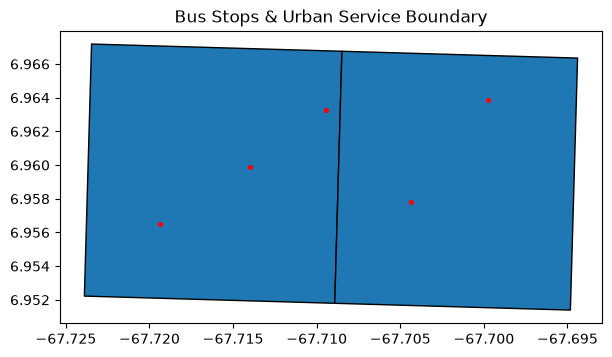

In [38]:
fig, ax = plt.subplots(figsize=(7,7))
urban_area.plot(ax=ax, edgecolor="black")
stops.plot(ax=ax, markersize=7, c="red") # make the marker size bigger if you would like to be able to see the dots
ax.set_title("Bus Stops & Urban Service Boundary")
plt.show()

The order that you call the layer will have an effect on how it is displayed. 
Notice the difference below when we call the points before the polygon.

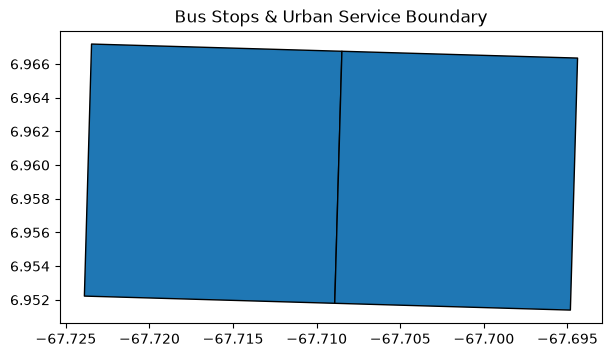

In [ ]:
fig, ax = plt.subplots(figsize=(7,7))
stops.plot(ax=ax, markersize=1, c="red")
urban_area.plot(ax=ax, edgecolor="black")
ax.set_title("Bus Stops & Urban Service Boundary")
plt.show()

# when you call the polygon first, they will layer on top of the bus stops and they will not be able to be seen

## Attribute filtering still works

In [40]:
list(stops.columns) ## to see all the columns 

['stop_id', 'stop_name', 'geometry']

In [41]:
stops["stop_name"].value_counts() # look at the column containing info about the "CL" route

stop_name
Stop A    1
Stop B    1
Stop C    1
Stop D    1
Stop E    1
Name: count, dtype: int64

In [47]:
#1 means that it has a stop and #0 means it does not
stops1 = stops[stops["stop_name"] == "A"].copy() ## selecting places where CL stops 
stops1

,stop_id,stop_name,geometry


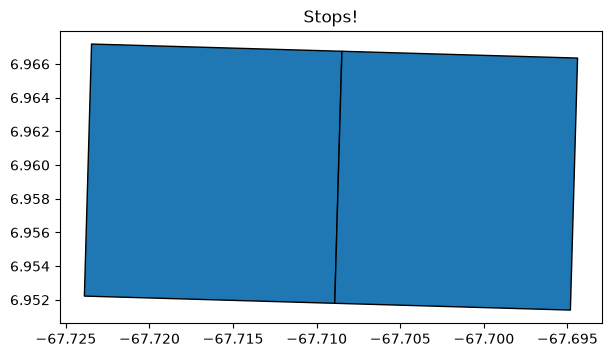

In [52]:
fig, ax = plt.subplots(figsize=(7,7))
parks.plot(ax=ax, markersize=7)
urban_area.plot(ax=ax, edgecolor="black")
ax.set_title("Stops!")
plt.show()

## Practice

Using another Chapel Hill geoJSON:

- download two geoJSONs from the Chapel Hill Server (not Stops, not the Boundary)
- inspect the type, shape, and columns
- select the name and geometry columns
- inspect the first geometry
- determine geometry types
- inspect the CRS
- filter the data
- make a copy of the result
- plot the selected features
- publish your work by uploading your JN to your GitHub (week06)


## What to remember

```python
gpd.read_file(...)
gdf.head()
gdf.shape
gdf.geometry
gdf.geom_type
gdf.crs
gdf.plot()
```

The main idea is that GeoPandas keeps the table structure of pandas and adds geometry.
